# 04 — Segmentation & Time-Series Analysis

Break conversion down by **device**, **region**, and **customer segment**, then analyze weekly open-rate / conversion-rate trends over the last 6 months.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
PAL=['#2E5EAA','#5BC0BE','#F4A259','#E76F51']
df = pd.read_csv('../data/cleaned_email_data.csv', parse_dates=['sent_date','sent_week'])
conv = lambda g: g.converted.sum()/g.delivered.sum()   # converted / delivered

## Step 6 — Conversion by each dimension

In [2]:
for dim in ['device_type','region','customer_segment']:
    print(f'\n{dim}:')
    print((df.groupby(dim).apply(conv, include_groups=False)*100).round(2))


device_type:
device_type
Desktop    3.98
Mobile     2.61
Tablet     2.87
dtype: float64

region:
region
East     3.07
North    3.69
South    2.99
West     2.75
dtype: float64

customer_segment:
customer_segment
New          2.52
Returning    3.67
VIP          3.47
dtype: float64


### Heatmap — conversion rate by device × region

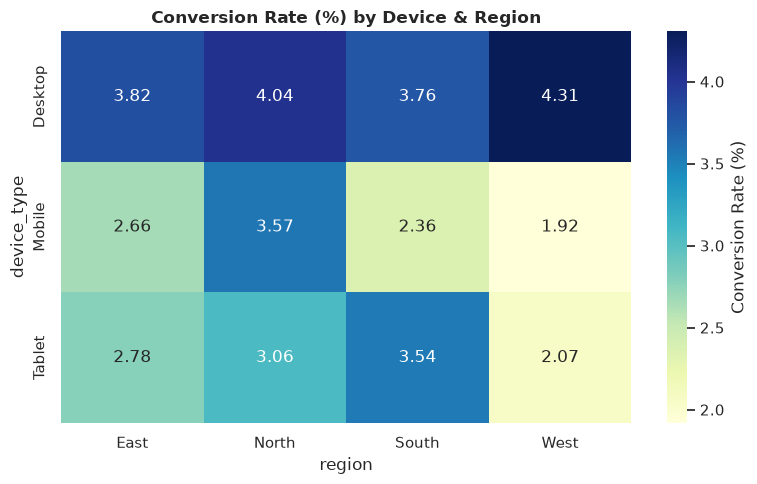

In [3]:
pivot = (df.pivot_table(index='device_type', columns='region', values='converted', aggfunc='sum') /
         df.pivot_table(index='device_type', columns='region', values='delivered', aggfunc='sum'))
fig, ax = plt.subplots(figsize=(8,5))
sns.heatmap(pivot*100, annot=True, fmt='.2f', cmap='YlGnBu', cbar_kws={'label':'Conversion Rate (%)'}, ax=ax)
ax.set_title('Conversion Rate (%) by Device & Region', weight='bold')
plt.tight_layout(); plt.savefig('../visuals/heatmap_device_region.png', dpi=120, bbox_inches='tight'); plt.show()

### Bar chart — conversion by customer segment

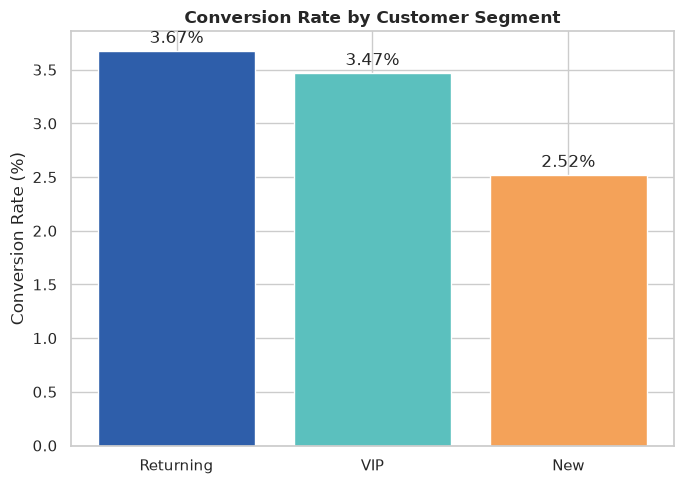

In [4]:
seg = df.groupby('customer_segment').apply(conv, include_groups=False).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7,5))
b = ax.bar(seg.index, seg.values*100, color=PAL[:3], edgecolor='white')
ax.set_title('Conversion Rate by Customer Segment', weight='bold'); ax.set_ylabel('Conversion Rate (%)')
ax.bar_label(b, fmt='%.2f%%', padding=3)
plt.tight_layout(); plt.savefig('../visuals/segment_conversion.png', dpi=120, bbox_inches='tight'); plt.show()

## Step 7 — Weekly time-series trend

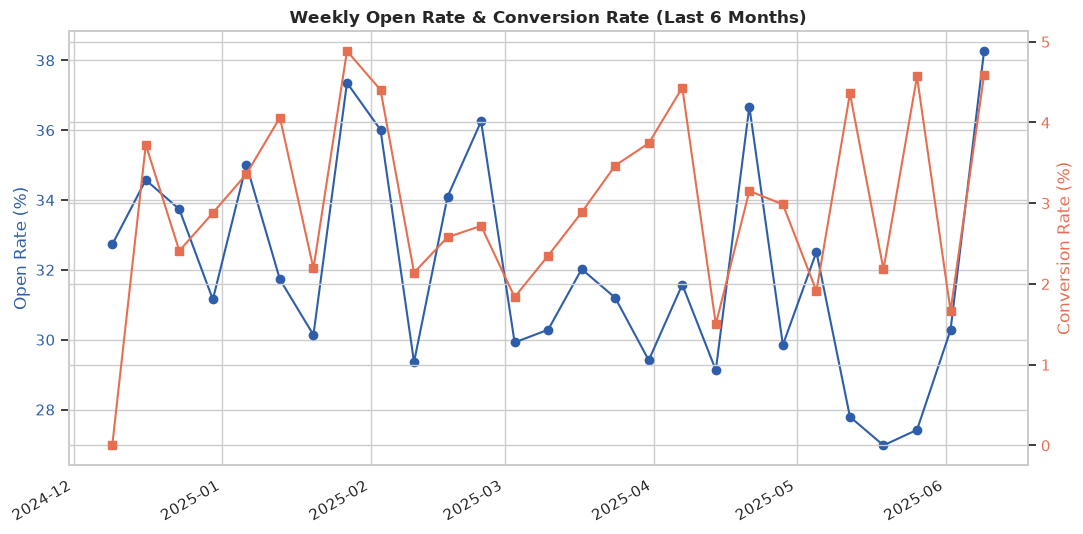

In [5]:
w = df.groupby('sent_week').agg(delivered=('delivered','sum'),opened=('opened','sum'),converted=('converted','sum')).reset_index()
w['open_rate']=w.opened/w.delivered; w['conv_rate']=w.converted/w.delivered
fig, ax = plt.subplots(figsize=(11,5.5))
ax.plot(w.sent_week, w.open_rate*100, marker='o', color=PAL[0], label='Open Rate')
ax.set_ylabel('Open Rate (%)', color=PAL[0]); ax.tick_params(axis='y', labelcolor=PAL[0])
ax2=ax.twinx(); ax2.plot(w.sent_week, w.conv_rate*100, marker='s', color=PAL[3], label='Conversion Rate')
ax2.set_ylabel('Conversion Rate (%)', color=PAL[3]); ax2.tick_params(axis='y', labelcolor=PAL[3])
ax.set_title('Weekly Open Rate & Conversion Rate (Last 6 Months)', weight='bold')
fig.autofmt_xdate(); plt.tight_layout(); plt.savefig('../visuals/time_series_trend.png', dpi=120, bbox_inches='tight'); plt.show()

## Step 8 — Key insights
1. **Desktop** is the strongest converting device — prioritize desktop-optimized layouts.
2. **Returning** and **VIP** segments convert best — invest in loyalty / retention.
3. The lowest-converting **region** warrants localized offers and send-time tests.
4. Weekly trends reveal the volatility of open vs. conversion rates — use for send-time planning.
5. Combined with the A/B result, these segments guide where to deploy the winning subject line first.

See `INSIGHTS.md` in the project root for the full recommendations and resume bullets.